# 나무 실루엣을 신경망으로 배우기 — Level Set의 아이디어

정원의 topiary(모양내 다듬은 나무) 사진을 보고 이런 질문이 나왔습니다:

> "이 실루엣을 신경망으로 근사할 수 있을까? 그런데 한 $x$에 $y$가 여러 개인데, 애초에 함수가 되긴 하나?"

맞는 지적입니다. 실루엣 곡선은 $y = f(x)$ 꼴이 **아닙니다** (수직선 하나가 경계와 여러 번 만납니다).
하지만 근사가 불가능한 것이 아니라, **표현을 바꾸면 됩니다**:

곡선을 직접 배우는 대신, 평면 위의 함수 $F(x, y)$ = "점 $(x,y)$가 나무 **안**일 확률"을 배웁니다.
$F$는 점 하나를 받아 숫자 하나를 내놓는 진짜 함수이므로 신경망으로 근사할 수 있고,
실루엣은 $F = 0.5$인 점들의 집합(**level set**)으로 복원됩니다.

1주차 수업의 표기로 쓰면, $\tilde{\xi} = (\text{점}, \text{안/밖 label})$로 두고

$$\min_{\theta}\; \mathbb{E}_{\mathbb{P}}\big[\, \ell(\tilde{y},\, F_{\theta}(\tilde{x})) \,\big]$$

— 완전히 표준적인 분류 문제가 됩니다. 단계별로 만들어 봅시다.

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(0)

INK, MUTED = "#1C232E", "#5A6472"
BLUE, GRAY, RED = "#2D5F8A", "#C9C2B6", "#A8402F"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})

## Step 1 — 나무를 "안/밖 판정 함수"로 정의하기

실루엣을 점의 목록으로 만들지 않습니다. 대신 **어떤 점이 나무 안인지 판정하는 함수** `inside(x, y)`를 만듭니다.
사진의 topiary처럼 원뿔(cone) + 정육면체(cube) + 공(ball) + 받침(base)을 세로로 쌓은 모양입니다.

그리고 왜 $y = f(x)$가 안 되는지 확인합니다: $x = 0.7$에 수직선을 그으면 경계와 **6번** 만납니다.

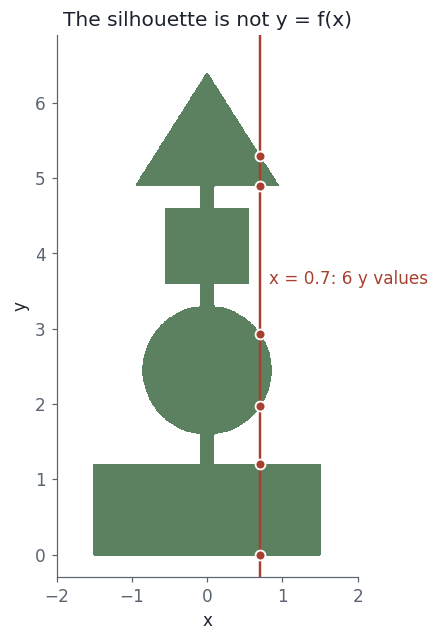

In [2]:
def inside(x, y):
    base   = (np.abs(x) <= 1.50) & (y >= 0.0) & (y <= 1.2)
    trunk1 = (np.abs(x) <= 0.09) & (y > 1.2) & (y <= 1.6)
    ball   = (x**2 + (y - 2.45)**2) <= 0.85**2
    trunk2 = (np.abs(x) <= 0.09) & (y > 3.3) & (y <= 3.6)
    cube   = (np.abs(x) <= 0.55) & (y > 3.6) & (y <= 4.6)
    trunk3 = (np.abs(x) <= 0.09) & (y > 4.6) & (y <= 4.9)
    cone   = (y > 4.9) & (y <= 6.4) & (np.abs(x) <= 0.95 * (6.4 - y) / 1.5)
    return base | trunk1 | ball | trunk2 | cube | trunk3 | cone

XL, XR, YB, YT = -2.0, 2.0, -0.3, 6.9
gx, gy = np.meshgrid(np.linspace(XL, XR, 400), np.linspace(YB, YT, 600))
occ = inside(gx, gy)

fig, ax = plt.subplots(figsize=(4.2, 6.4))
ax.contourf(gx, gy, occ.astype(float), levels=[0.5, 1.5], colors=["#3E6B44"], alpha=0.85)
x0 = 0.7
ax.axvline(x0, color=RED, lw=1.6)
crossings = [0.0, 1.2, 1.97, 2.93, 4.9, 5.295]
ax.scatter([x0] * len(crossings), crossings, s=42, color=RED, zorder=5,
           edgecolor="white", linewidth=1.2)
ax.annotate(f"x = {x0}: {len(crossings)} y values", (x0 + 0.12, 3.6), color=RED, fontsize=11)
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("The silhouette is not y = f(x)", color=INK)
plt.show()

## Step 2 — 훈련 데이터 만들기

상자 안에서 점을 무작위로 뽑고, 각 점에 label을 붙입니다: 나무 **안이면 1, 밖이면 0**.

이것이 $\tilde{\xi} = (\tilde{x}, \tilde{y})$입니다 — 입력 $\tilde{x}$는 평면 위의 점(숫자 2개), 출력 label $\tilde{y}$는 0 또는 1.

훈련 32000개, 평가 8000개, 나무 안 비율 0.302


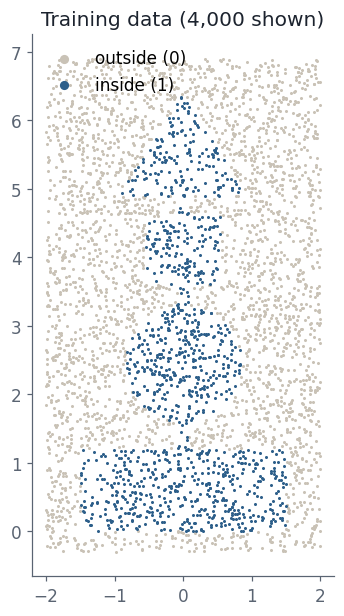

In [3]:
N = 40000
pts = np.column_stack([rng.uniform(XL, XR, N), rng.uniform(YB, YT, N)])
lab = inside(pts[:, 0], pts[:, 1]).astype(int)
Xtr, Xte, ytr, yte = train_test_split(pts, lab, test_size=0.2, random_state=0)
print(f"훈련 {len(Xtr)}개, 평가 {len(Xte)}개, 나무 안 비율 {lab.mean():.3f}")

fig, ax = plt.subplots(figsize=(4.2, 6.4))
show = rng.choice(len(Xtr), 4000, replace=False)
for cls, color, name in [(0, GRAY, "outside (0)"), (1, BLUE, "inside (1)")]:
    m = show[ytr[show] == cls]
    ax.scatter(Xtr[m, 0], Xtr[m, 1], s=4, color=color, label=name, linewidths=0)
ax.set_aspect("equal"); ax.legend(loc="upper left", frameon=False, markerscale=3)
ax.set_title("Training data (4,000 shown)", color=INK)
plt.show()

## Step 3 — 신경망 $F_\theta$ 학습

$F_\theta:\ \mathbb{R}^2 \to [0, 1]$, 은닉층 3개짜리 작은 신경망입니다.
`fit` 한 줄이 곧 $\min_\theta \mathbb{E}_{\hat{\mathbb{P}}_N}[\ell]$을 푸는 것입니다 (손실 $\ell$ = log loss).

In [4]:
clf = MLPClassifier(hidden_layer_sizes=(64, 64, 64), activation="tanh",
                    alpha=1e-5, max_iter=1000, random_state=0)
clf.fit(Xtr, ytr)
print(f"평가 정확도: {clf.score(Xte, yte):.4f}")

평가 정확도: 0.9878


## Step 4 — Level set으로 실루엣 복원

학습된 $F_\theta$를 평면 전체에서 평가한 뒤, $F_\theta = 0.5$인 등고선을 그립니다. 그 등고선이 복원된 실루엣입니다.

$x$ 하나에 $y$가 여러 개라는 문제는 사라졌습니다 — 곡선을 $y=f(x)$로 배운 것이 아니라,
**함수 $F$의 level set으로 곡선을 얻었기** 때문입니다.

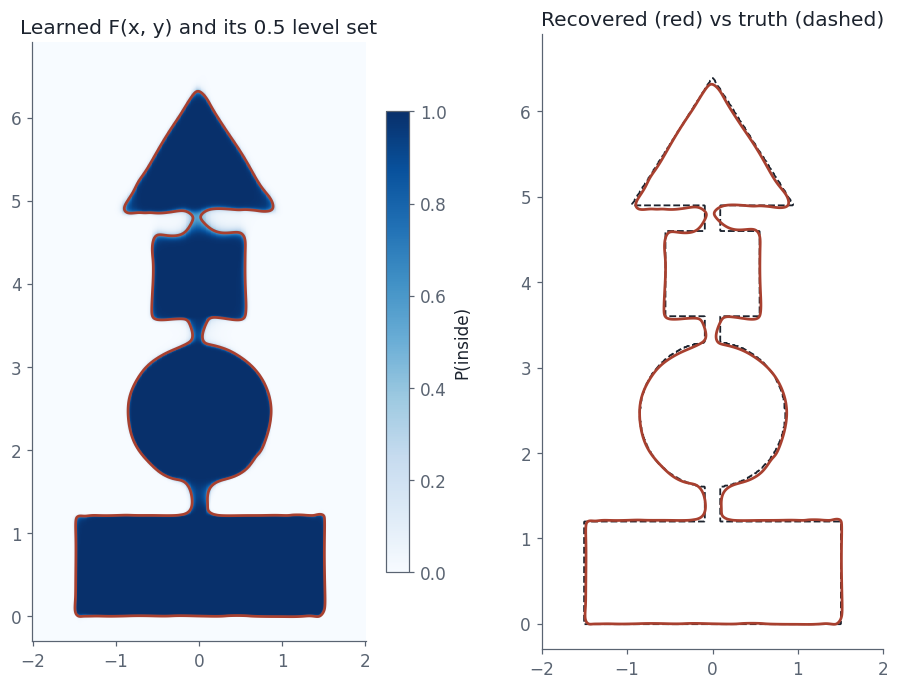

In [5]:
prob = clf.predict_proba(np.column_stack([gx.ravel(), gy.ravel()]))[:, 1].reshape(gx.shape)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 6.4))
im = axes[0].pcolormesh(gx, gy, prob, cmap="Blues", vmin=0, vmax=1, shading="auto")
axes[0].contour(gx, gy, prob, levels=[0.5], colors=[RED], linewidths=1.8)
axes[0].set_title("Learned F(x, y) and its 0.5 level set", color=INK)
fig.colorbar(im, ax=axes[0], shrink=0.75, label="P(inside)")
axes[1].contour(gx, gy, occ.astype(float), levels=[0.5], colors=[INK],
                linewidths=1.2, linestyles="dashed")
axes[1].contour(gx, gy, prob, levels=[0.5], colors=[RED], linewidths=1.8)
axes[1].set_title("Recovered (red) vs truth (dashed)", color=INK)
for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## Step 5 — 경계가 자라나는 과정

학습을 1번, 5번, 20번, … 반복한 시점마다 $F_\theta = 0.5$ 영역을 그려 보면,
신경망이 실루엣을 어떻게 조금씩 찾아가는지 보입니다.

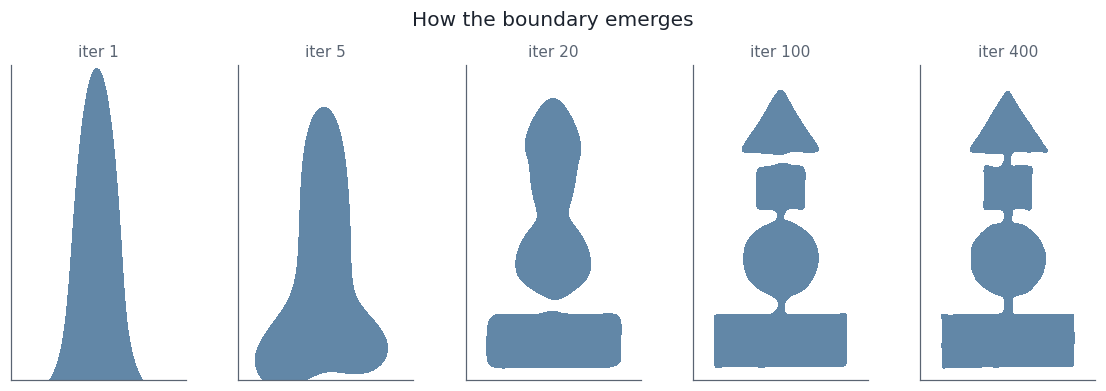

In [6]:
snaps, iters = [], [1, 5, 20, 100, 400]
clf2 = MLPClassifier(hidden_layer_sizes=(64, 64, 64), activation="tanh",
                     alpha=1e-5, max_iter=1, warm_start=True, random_state=0)
done = 0
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for target in iters:
        while done < target:
            clf2.fit(Xtr, ytr); done += 1
        p = clf2.predict_proba(np.column_stack([gx.ravel(), gy.ravel()]))[:, 1].reshape(gx.shape)
        snaps.append((target, p))

fig, axes = plt.subplots(1, len(snaps), figsize=(2.1 * len(snaps), 3.6))
for ax, (it, p) in zip(axes, snaps):
    ax.contourf(gx, gy, p, levels=[0.5, 1.5], colors=[BLUE], alpha=0.75)
    ax.set_title(f"iter {it}", fontsize=10, color=MUTED)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("How the boundary emerges", color=INK)
plt.tight_layout(); plt.show()

## 정리

- 실루엣은 $y = f(x)$가 아니지만, **"이 점이 안인가?"라는 함수 $F(x,y)$는 언제나 잘 정의**됩니다.
- 신경망은 $F$를 근사하고, 곡선은 $F = 0.5$의 **level set**으로 복원됩니다.
- 같은 아이디어를 3차원에 쓰면 DeepSDF, occupancy network 등 최신 3D 형상 학습이 됩니다.
- 교훈: **"함수가 아니라서 못 배운다"가 아니라, "무엇을 함수로 볼지"를 고르는 것이 모델링**입니다.